In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import stats,ttest_1samp, ttest_ind, ttest_rel, f_oneway, chi2_contingency
from scipy.stats import norm

In [ ]:
#Jack: Setting up pandas to read CSV files from Google Drive
inventory_ID = '1z1E0--qe62C8-uVyMiRb6Z-_H8kiXX4j'
#https://drive.google.com/file/d/1z1E0--qe62C8-uVyMiRb6Z-_H8kiXX4j/view?usp=sharing
product_ID = '1R2kuJIraqI9zRVu2CBLiNv8fDoUjmH9o'
#https://drive.google.com/file/d/1R2kuJIraqI9zRVu2CBLiNv8fDoUjmH9o/view?usp=sharing
sales_ID = '1EQ345GLRYnUCkcvZyMQh8bulmSnnyQ21'
#https://drive.google.com/file/d/1EQ345GLRYnUCkcvZyMQh8bulmSnnyQ21/view?usp=sharing
store_ID = '1f_wds8-f1aKmCfTkXJDk0yuThDvSe-wR'
#https://drive.google.com/file/d/1f_wds8-f1aKmCfTkXJDk0yuThDvSe-wR/view?usp=sharing
supplier_ID = '1_Wh4rZvXmeLcJJNrWPYJBCXhdLxo_H5d'
#https://drive.google.com/file/d/1_Wh4rZvXmeLcJJNrWPYJBCXhdLxo_H5d/view?usp=sharing



inventory_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={inventory_ID}')
product_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={product_ID}')
sales_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={sales_ID}')
store_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={store_ID}')
supplier_df = pd.read_csv(f'https://drive.google.com/uc?export=download&id={supplier_ID}')

In [ ]:
inventory_df.head(10)

,store_id,product_id,stock_level,storage_cost,ordering_cost,stockout_cost
0,S001,P0114,55.0,0.68,62.82,42.56
1,S001,P0042,165.0,0.30,54.42,33.14
2,S001,P0089,68.0,0.49,36.60,27.10
3,S001,P0081,193.0,0.72,26.72,22.25
4,S001,P0058,100.0,0.72,67.69,41.69
5,S001,P0048,115.0,0.96,64.15,14.69
6,S001,P0004,28.0,0.78,66.69,49.69
7,S001,P0095,95.0,0.44,38.62,36.12
8,S001,P0178,47.0,0.58,69.39,33.16
9,S001,P0036,125.0,0.80,39.19,36.95


In [ ]:
product_df.head(10)

,product_id,category,product_name,perishable_flag
0,P0001,Beverages,Dairy Item 1,0
1,P0002,Dairy,Bakery Item 2,1
2,P0003,Dairy,Frozen Item 3,1
3,P0004,Beverages,Dairy Item 4,0
4,P0005,Produce,Dairy Item 5,1
5,P0006,Bakery,Beverages Item 6,0
6,P0007,Bakery,Meat Item 7,0
7,P0008,Bakery,Dairy Item 8,0
8,P0009,Beverages,Frozen Item 9,0
9,P0010,Dairy,Bakery Item 10,1


In [ ]:
sales_df.head(10)

,store_id,product_id,quantity_sold,promo_flag,price,date
0,S009,P0108,2,0,9.88,2024-09-07
1,S019,P0099,4,0,6.77,2024-10-21
2,S015,P0073,3,1,2.18,2024-06-30
3,S001,P0018,8,0,16.85,2024-03-01
4,S011,P0127,10,0,8.78,2024-12-14
5,S004,P0096,10,0,2.04,2023-02-18
6,S005,P0027,6,1,5.69,2023-04-01
7,S024,P0095,9,0,18.78,2023-02-23
8,S002,P0029,1,1,2.89,2023-12-04
9,S019,P0118,2,0,7.41,2023-06-01


In [ ]:
#Jack: Display NAN values and duplicates that are in Sale Dataframe
print("NAN values in sales dataframe:\n", sales_df.isna().sum())
print()
print("Number of Duplicates in the sales dataframe: ", sales_df.duplicated().sum())

NAN values in sales dataframe:
 store_id           0
product_id         0
quantity_sold      0
promo_flag         0
price            212
date               0
dtype: int64

Number of Duplicates in the sales dataframe:  100


In [ ]:
store_df.head()

,store_id,region,size,opening_date
0,S001,West,Medium,2019-11-11
1,S002,East,Medium,2017-08-03
2,S003,Central,Medium,2016-01-08
3,S004,West,Small,2015-04-13
4,S005,West,Medium,2016-06-16


In [ ]:
supplier_df.head(10)

,supplier_id,product_id,lead_time_days,unit_cost,on_time_delivery_rate,defect_rate
0,SUP07,P0001,6,6.77,0.74,0.05
1,SUP01,P0001,14,8.99,0.70,0.03
2,SUP08,P0001,13,1.68,0.81,0.04
3,SUP06,P0002,8,1.32,0.76,0.08
4,SUP10,P0002,8,7.34,0.95,0.03
5,SUP02,P0003,7,1.19,0.70,0.07
6,SUP06,P0003,6,9.33,0.96,0.07
7,SUP08,P0004,7,0.56,0.82,0.06
8,SUP01,P0005,12,8.83,0.98,0.07
9,SUP09,P0005,9,1.99,0.72,0.05


In [ ]:
#Jack: identifying NAN values and Duplicates in Supplier data frame
print("NAN values in supplier dataframe:\n", supplier_df.isna().sum())
print()
print("Number of Duplicates in the supplier dataframe: ", supplier_df.duplicated().sum())

NAN values in supplier dataframe:
 supplier_id              0
product_id               0
lead_time_days           0
unit_cost                0
on_time_delivery_rate    0
defect_rate              0
dtype: int64

Number of Duplicates in the supplier dataframe:  0


In [ ]:
#Shilpa: Remove the duplicate value
sales_df.drop_duplicates(inplace=True)
print("NAN values in sales dataframe:\n", sales_df.isna().sum())
print()
print("Number of Duplicates in the sales dataframe: ", sales_df.duplicated().sum())

NAN values in sales dataframe:
 store_id           0
product_id         0
quantity_sold      0
promo_flag         0
price            200
date               0
dtype: int64

Number of Duplicates in the sales dataframe:  0


In [ ]:
#Shilpa: Find out the missing values in inevntory
print("Missing values per column:")
print(inventory_df.isnull().sum())
print("\nTotal missing values in dataset:", inventory_df.isnull().sum().sum())

Missing values per column:
store_id          0
product_id        0
stock_level      75
storage_cost      0
ordering_cost     0
stockout_cost     0
dtype: int64

Total missing values in dataset: 75


In [ ]:
#Shilpa: Find out the missing values in product
print("Missing values per column:")
print(product_df.isnull().sum())
print("\nTotal missing values in dataset:", product_df.isnull().sum().sum())

Missing values per column:
product_id         0
category           0
product_name       0
perishable_flag    0
dtype: int64

Total missing values in dataset: 0


In [ ]:
#Shilpa: Find out the missing values in sales
print("Missing values per column:")
print(sales_df.isnull().sum())
print("\nTotal missing values in dataset:", sales_df.isnull().sum().sum())

Missing values per column:
store_id           0
product_id         0
quantity_sold      0
promo_flag         0
price            200
date               0
dtype: int64

Total missing values in dataset: 200


In [ ]:
#Shilpa: Find out the missing values store
print("Missing values per column:")
print(store_df.isnull().sum())
print("\nTotal missing values in dataset:", store_df.isnull().sum().sum())

Missing values per column:
store_id        0
region          0
size            0
opening_date    0
dtype: int64

Total missing values in dataset: 0


In [ ]:
#Shilpa: Find out the missing values supplier
print("Missing values per column:")
print(supplier_df.isnull().sum())
print("\nTotal missing values in dataset:", supplier_df.isnull().sum().sum())

Missing values per column:
supplier_id              0
product_id               0
lead_time_days           0
unit_cost                0
on_time_delivery_rate    0
defect_rate              0
dtype: int64

Total missing values in dataset: 0


In [ ]:
#Jack and Shilpa: drop the missing values from inventory dataframe
inventory_df = inventory_df.dropna()
print("Missing values per column:")
print(inventory_df.isnull().sum())
print("\nTotal missing values in dataset:", inventory_df.isnull().sum().sum())

Missing values per column:
store_id         0
product_id       0
stock_level      0
storage_cost     0
ordering_cost    0
stockout_cost    0
dtype: int64

Total missing values in dataset: 0


In [ ]:
#Jack: Change stock level in inventory dataframe from float to integer
inventory_df['stock_level'] = inventory_df['stock_level'].astype(int)
inventory_df.head()

,store_id,product_id,stock_level,storage_cost,ordering_cost,stockout_cost
0,S001,P0114,55,0.68,62.82,42.56
1,S001,P0042,165,0.30,54.42,33.14
2,S001,P0089,68,0.49,36.60,27.10
3,S001,P0081,193,0.72,26.72,22.25
4,S001,P0058,100,0.72,67.69,41.69


In [ ]:
#Jack and Shilpa: drop the missing values in sales dataframe
sales_df = sales_df.dropna()
print("Missing values per column:")
print(sales_df.isnull().sum())
print("\nTotal missing values in dataset:", sales_df.isnull().sum().sum())

Missing values per column:
store_id         0
product_id       0
quantity_sold    0
promo_flag       0
price            0
date             0
dtype: int64

Total missing values in dataset: 0


In [ ]:
#Shilpa: fixing inconsistent formats in sales
sales_df['date'] = pd.to_datetime(sales_df['date'], errors='coerce')
print("Rows with invalid dates:")
print(sales_df[sales_df['date'].isna()])
sales_df.head()

Rows with invalid dates:
Empty DataFrame
Columns: [store_id, product_id, quantity_sold, promo_flag, price, date]
Index: []


,store_id,product_id,quantity_sold,promo_flag,price,date
0,S009,P0108,2,0,9.88,2024-09-07
1,S019,P0099,4,0,6.77,2024-10-21
2,S015,P0073,3,1,2.18,2024-06-30
3,S001,P0018,8,0,16.85,2024-03-01
4,S011,P0127,10,0,8.78,2024-12-14


In [ ]:
#Jack: Describing the inventory data
inventory_df.describe()

,stock_level,storage_cost,ordering_cost,stockout_cost
count,2425.000000,2425.000000,2425.000000,2425.000000
mean,108.743505,0.545625,59.684870,30.004082
std,52.112638,0.257213,23.054154,11.487892
min,20.000000,0.100000,20.000000,10.000000
25%,65.000000,0.320000,39.970000,20.420000
50%,109.000000,0.550000,59.210000,30.080000
75%,153.000000,0.760000,79.120000,39.690000
max,200.000000,1.000000,99.990000,49.990000


In [ ]:
#Jack: Info on the inventory data
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2425 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   store_id       2425 non-null   object 
 1   product_id     2425 non-null   object 
 2   stock_level    2425 non-null   int64  
 3   storage_cost   2425 non-null   float64
 4   ordering_cost  2425 non-null   float64
 5   stockout_cost  2425 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 132.6+ KB


In [ ]:
#Jack: Describing the sales data
sales_df.describe()

,quantity_sold,promo_flag,price,date
count,3724.000000,3724.000000,3724.000000,3724
mean,5.418367,0.502685,10.810030,2024-01-06 04:04:22.943072
min,1.000000,0.000000,1.510000,2023-01-01 00:00:00
25%,3.000000,0.000000,6.157500,2023-07-10 00:00:00
50%,5.000000,1.000000,10.865000,2024-01-11 00:00:00
75%,8.000000,1.000000,15.492500,2024-07-04 00:00:00
max,10.000000,1.000000,19.990000,2024-12-31 00:00:00
std,2.923236,0.500060,5.359355,NaN


In [ ]:
#Jack: Info on the sales data
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3724 entries, 0 to 3923
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   store_id       3724 non-null   object        
 1   product_id     3724 non-null   object        
 2   quantity_sold  3724 non-null   int64         
 3   promo_flag     3724 non-null   int64         
 4   price          3724 non-null   float64       
 5   date           3724 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 203.7+ KB


In [ ]:
#Jack: Describing the supplier data
supplier_df.describe()

,lead_time_days,unit_cost,on_time_delivery_rate,defect_rate
count,383.000000,383.000000,383.000000,383.000000
mean,8.101828,5.282037,0.856710,0.055875
std,3.736416,2.824039,0.088188,0.026442
min,2.000000,0.500000,0.700000,0.010000
25%,5.000000,2.805000,0.780000,0.030000
50%,8.000000,5.160000,0.870000,0.060000
75%,11.000000,7.940000,0.940000,0.080000
max,14.000000,9.970000,1.000000,0.100000


In [ ]:
#Jack: Info on the inventory data
supplier_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   supplier_id            383 non-null    object 
 1   product_id             383 non-null    object 
 2   lead_time_days         383 non-null    int64  
 3   unit_cost              383 non-null    float64
 4   on_time_delivery_rate  383 non-null    float64
 5   defect_rate            383 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 18.1+ KB


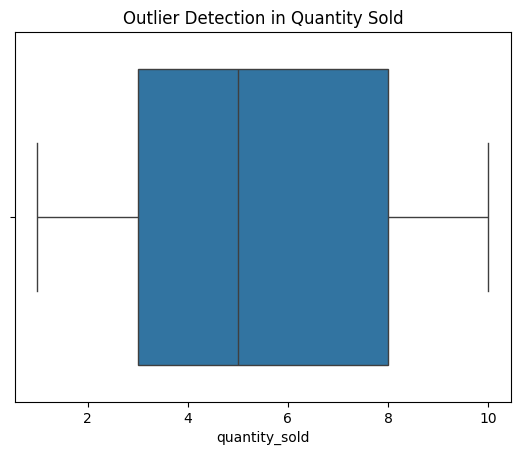

In [ ]:
#Jack: Outlier detection in sales dataframe, quantity_sold column
sns.boxplot(x=sales_df['quantity_sold'])
plt.title("Outlier Detection in Quantity Sold")
plt.show()
#Result - No outliers

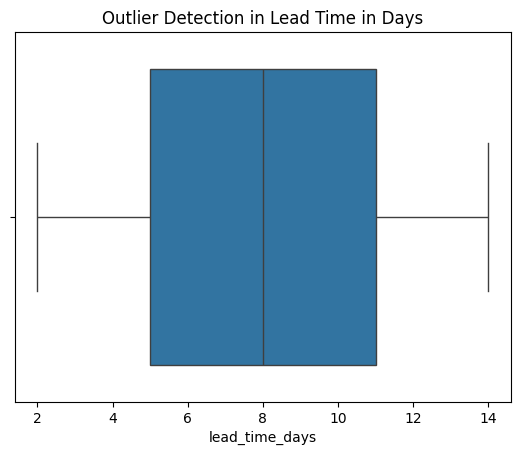

In [ ]:
#Jack: Outlier detection in supplier dataframe, lead_time_days column
sns.boxplot(x=supplier_df['lead_time_days'])
plt.title("Outlier Detection in Lead Time in Days")
plt.show()
#Result - No outliers

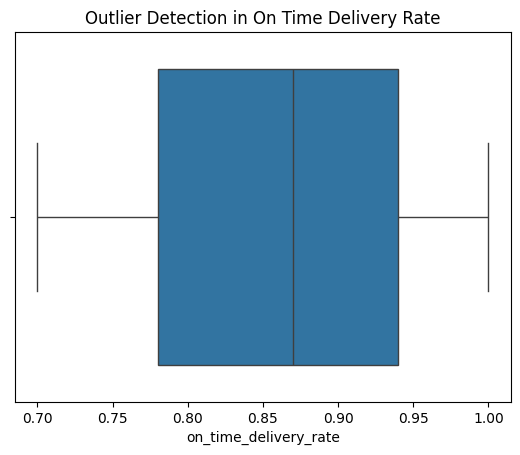

In [ ]:
#Jack: Outlier detection in supplier dataframe, on_time_delivery_rate	column
sns.boxplot(x=supplier_df['on_time_delivery_rate'])
plt.title("Outlier Detection in On Time Delivery Rate")
plt.show()
#Result - No outliers

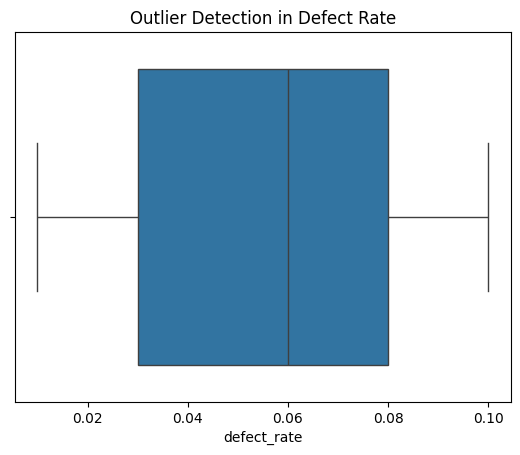

In [ ]:
#Jack: Outlier detection in supplier dataframe, defect_rate	column
sns.boxplot(x=supplier_df['defect_rate'])
plt.title("Outlier Detection in Defect Rate")
plt.show()
#Result - No outliers

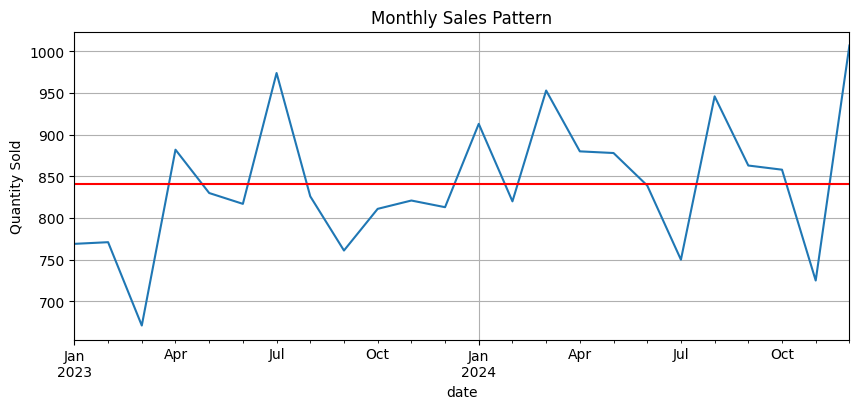


The Average line is 840.75 Units Sold


In [ ]:
#Jack: Monthly Sales Pattern
just_sales_M = sales_df
just_sales_M = just_sales_M.set_index('date')

monthly_df = just_sales_M['quantity_sold'].resample('ME').sum().to_frame(name='Monthly_Sales')
monthly_df['Month_Name'] = monthly_df.index.strftime('%B')
monthly_df['Year'] = monthly_df.index.year
monthly_df['Month_Num'] = monthly_df.index.month

monthly_df['Monthly_Sales'].plot(figsize=(10, 4), title="Monthly Sales Pattern")
plt.axhline(monthly_df['Monthly_Sales'].mean(), color='r')
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.show()

print(f"\nThe Average line is {monthly_df['Monthly_Sales'].mean()} Units Sold")

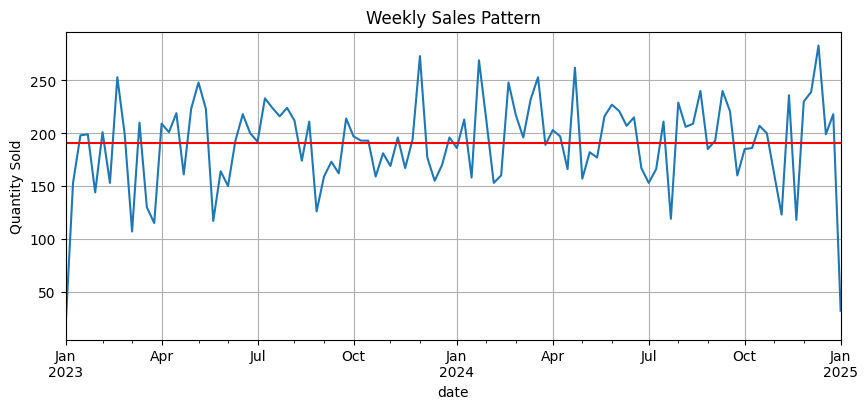


The Average line is 190.35849056603774 Units Sold


In [ ]:
#Jack: Weekly Sales Pattern
just_sales_W = sales_df
just_sales_W = just_sales_W.set_index('date')

weekly_df = just_sales_W['quantity_sold'].resample('W').sum().to_frame(name='Weekly_Sales')
weekly_df['Week_Name'] = weekly_df.index.strftime('%B')
weekly_df['Year'] = weekly_df.index.year
weekly_df['Week_Num'] = weekly_df.index.month

weekly_df['Weekly_Sales'].plot(figsize=(10, 4), title="Weekly Sales Pattern")
plt.axhline(weekly_df['Weekly_Sales'].mean(), color='r')
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.show()

print(f"\nThe Average line is {weekly_df['Weekly_Sales'].mean()} Units Sold")

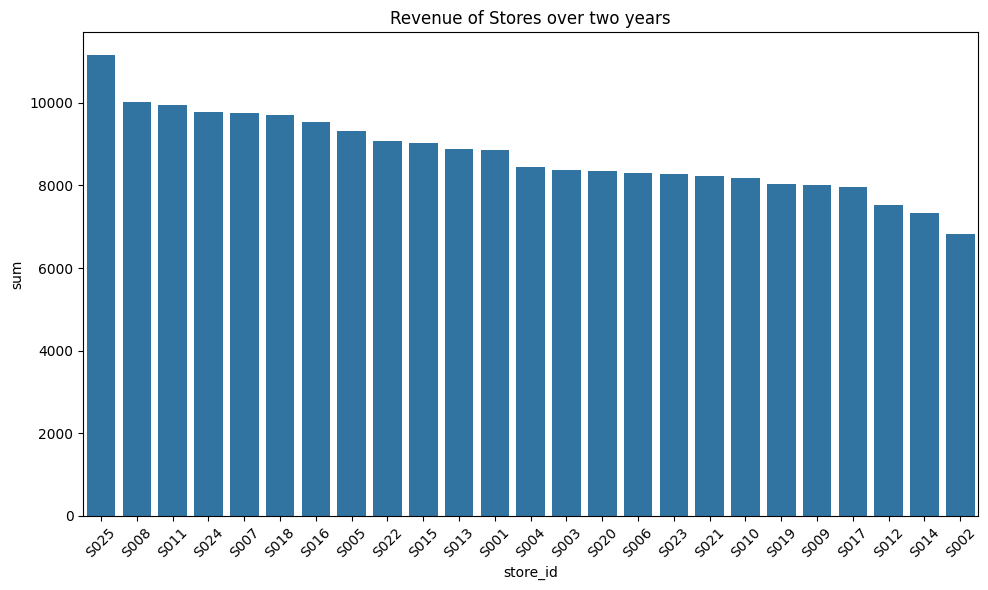


Top three stores with the best Revenue are:
                sum
store_id          
S025      11150.99
S008      10015.23
S011       9949.98


In [ ]:
#Jack: Revenue Chart for stores
sales_df['Revenue'] = sales_df['quantity_sold'] * sales_df['price']

store_rev = sales_df.groupby('store_id')['Revenue'].agg(['sum'])
store_rev = store_rev.sort_values(by='sum',ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=store_rev, x="store_id", y="sum")
plt.title("Revenue of Stores over two years")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTop three stores with the best Revenue are:\n {store_rev[:3]}")

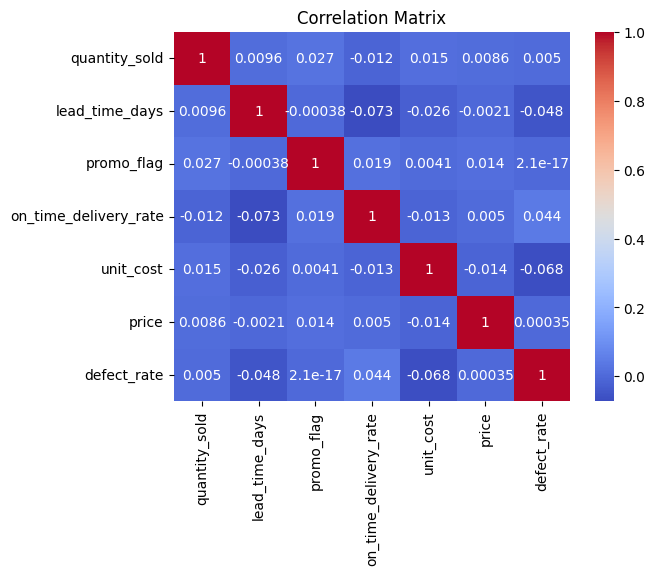

In [ ]:
#Jack: Correlation matrix for all categories in the sales and supplier data frames
Correlations = pd.merge(sales_df, supplier_df, on  = 'product_id', how = 'inner')

correlation_matrix = Correlations[['quantity_sold', 'lead_time_days', 'promo_flag', 'on_time_delivery_rate','unit_cost', 'price', 'defect_rate']].corr()
text = "Correlation Analysis of Quantity Sold, Lead time, promotions, On-Time Delivery, Unit Cost, Price, Defect Rate"

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


            Weekly_Sales  WMA_3  Diff
date                                 
2024-11-03           161  181.9 -20.9
2024-11-10           123  149.8 -26.8
2024-11-17           236  187.1  48.9
2024-11-24           118  154.4 -36.4
2024-12-01           230  197.6  32.4
2024-12-08           239  212.1  26.9
2024-12-15           283  259.2  23.8
2024-12-22           199  232.2 -33.2
2024-12-29           218  225.3  -7.3
2025-01-05            32  121.2 -89.2

The mean absolute error is 0.197
The mean squared error is 594.182
The mean absolute percentage error is 19.712%



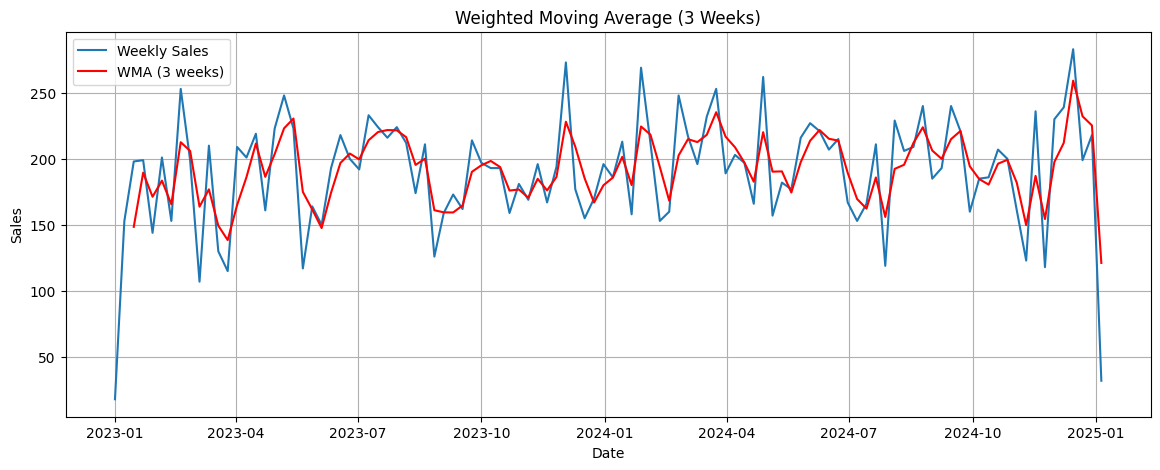

In [ ]:
#Jack: Weighted Moving Average is the best forecasting model for this data
def weighted_moving_average(series, weights):

    weights = np.array(weights)
    window = len(weights)

    return series.rolling(window).apply(lambda x: np.dot(x, weights), raw=True)


weights = [0.2, 0.3, 0.5]
weekly_df['WMA_3'] = weighted_moving_average(weekly_df['Weekly_Sales'], weights)
weekly_df['Diff'] = weekly_df['Weekly_Sales'] - weekly_df['WMA_3']
print(weekly_df[['Weekly_Sales', 'WMA_3', 'Diff']].tail(10))
print()
print(f"The mean absolute error is {np.abs(weekly_df['Diff'].mean()):.3f}")
print(f"The mean squared error is {np.square(weekly_df['Diff']).mean():.3f}")
print(f"The mean absolute percentage error is {(np.abs(weekly_df['Diff'].mean()))*100:.3f}%")
print()
plt.figure(figsize=(14, 5))
plt.plot(weekly_df.index, weekly_df['Weekly_Sales'], label='Weekly Sales')
plt.plot(weekly_df.index, weekly_df['WMA_3'], label='WMA (3 weeks)', color='red')
plt.title('Weighted Moving Average (3 Weeks)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Jack: Setting up forecasting for Store S025
most_sold = sales_df.groupby('store_id')['quantity_sold'].sum()
most_sold = most_sold.sort_values(ascending=False)

sales_S025 = sales_df[sales_df['store_id'] == "S025"]
sales_S025 = sales_S025.set_index('date')

weekly_df_S025 = sales_S025['quantity_sold'].resample('W').sum().to_frame(name='Weekly_Sales')
weekly_df_S025['Week_Name'] = weekly_df_S025.index.strftime('%B')
weekly_df_S025['Year'] = weekly_df_S025.index.year
weekly_df_S025['Week_Num'] = weekly_df_S025.index.month

most_sold.head()

,quantity_sold
store_id,
S025,1039
S024,918
S007,909
S008,904
S016,904


            Weekly_Sales  WMA_3  Diff
date                                 
2024-10-20             7    8.4  -1.4
2024-10-27            15    9.8   5.2
2024-11-03             0    5.9  -5.9
2024-11-10             0    3.0  -3.0
2024-11-17             4    2.0   2.0
2024-11-24             5    3.7   1.3
2024-12-01             0    2.3  -2.3
2024-12-08             3    2.5   0.5
2024-12-15            24   12.9  11.1
2024-12-22            16   15.8   0.2

The mean absolute error is 0.104
The mean squared error is 28.224
The mean absolute percentage error is 10.396%



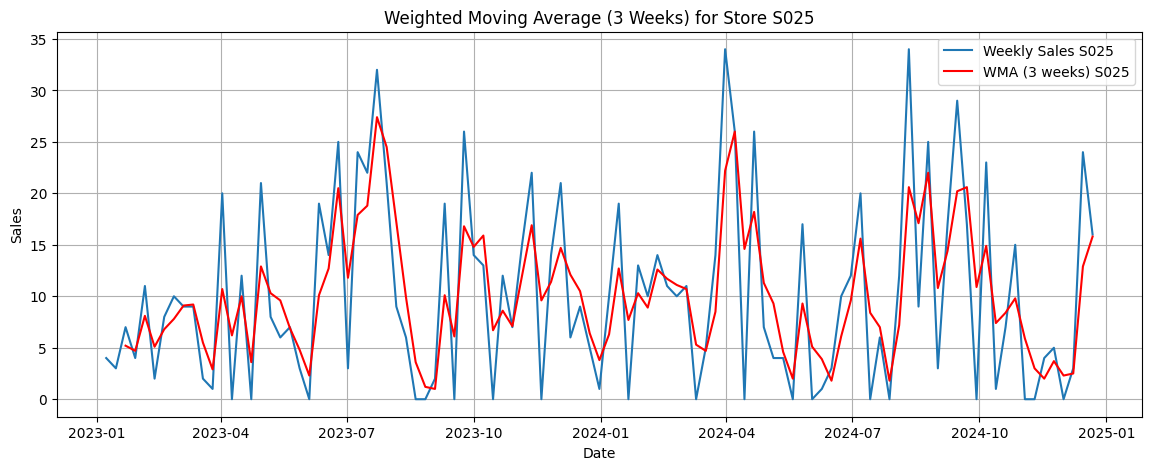

In [ ]:
#Jack: Forecasting demand at Store S025 via Weighted Moving Average
def weighted_moving_average(series, weights):

    weights = np.array(weights)
    window = len(weights)

    return series.rolling(window).apply(lambda x: np.dot(x, weights), raw=True)


weights = [0.2, 0.3, 0.5]
weekly_df_S025['WMA_3'] = weighted_moving_average(weekly_df_S025['Weekly_Sales'], weights)
weekly_df_S025['Diff'] = weekly_df_S025['Weekly_Sales'] - weekly_df_S025['WMA_3']
print(weekly_df_S025[['Weekly_Sales', 'WMA_3', 'Diff']].tail(10))
print()
print(f"The mean absolute error is {np.abs(weekly_df_S025['Diff'].mean()):.3f}")
print(f"The mean squared error is {np.square(weekly_df_S025['Diff']).mean():.3f}")
print(f"The mean absolute percentage error is {(np.abs(weekly_df_S025['Diff'].mean()))*100:.3f}%")
print()
plt.figure(figsize=(14, 5))
plt.plot(weekly_df_S025.index, weekly_df_S025['Weekly_Sales'], label='Weekly Sales S025')
plt.plot(weekly_df_S025.index, weekly_df_S025['WMA_3'], label='WMA (3 weeks) S025', color='red')
plt.title('Weighted Moving Average (3 Weeks) for Store S025')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Jack and Shilpa: Two-sample t-test:sales with promotion and without promotion are same
promotion = sales_df[sales_df['promo_flag'] == 1]['quantity_sold']
without_promotion = sales_df[sales_df['promo_flag'] == 0]['quantity_sold']

t_stat, p_value = ttest_ind(promotion, without_promotion)

explanation_2 = "Reject null: sales with promotion and without promotion are different" if p_value < 0.05 else "Fail to reject null: sales with promotion and without promotion are same."

print("\n--- Hypothesis Test Results ---")
print(f"\n 2. Two-sample t-test: t = {t_stat:.2f}, p = {p_value:.4f} → {explanation_2}")


--- Hypothesis Test Results ---

 2. Two-sample t-test: t = 1.47, p = 0.1425 → Fail to reject null: sales with promotion and without promotion are same.


In [ ]:
#Shilpa: Two-sample t-test: sales with promotion and without promotion are same in each region
merged_df = pd.merge(sales_df, store_df, on='store_id')

print("--- Hypothesis Test Results by Region (Promotion vs No Promotion) ---")

# Get unique regions
regions = merged_df['region'].unique()

# Iterate through each region
for region in regions:
    print(f"\nAnalyzing region: {region}")

    # Filter data for the current region
    region_data = merged_df[merged_df['region'] == region]

    # Separate quantity_sold for sales with and without promotion in the current region
    promotion_sales = region_data[region_data['promo_flag'] == 1]['quantity_sold'].dropna()
    without_promotion_sales = region_data[region_data['promo_flag'] == 0]['quantity_sold'].dropna()

    # Perform the two-sample t-test
    # Check if there are enough samples in both groups (at least 2 in each for t-test)
    if len(promotion_sales) >= 2 and len(without_promotion_sales) >= 2:
        t_stat, p_value = ttest_ind(promotion_sales, without_promotion_sales)

        explanation = "Reject null: sales quantity with promotion and without promotion are statistically different in this region." if p_value < 0.05 else "Fail to reject null: no statistically significant difference in sales quantity with promotion and without promotion in this region."

        print(f"Two-sample t-test: t = {t_stat:.2f}, p = {p_value:.4f} → {explanation}")
    else:
        print("Not enough data in one or both groups to perform t-test in this region.")

--- Hypothesis Test Results by Region (Promotion vs No Promotion) ---

Analyzing region: West
Two-sample t-test: t = 0.87, p = 0.3863 → Fail to reject null: no statistically significant difference in sales quantity with promotion and without promotion in this region.

Analyzing region: North
Two-sample t-test: t = -1.35, p = 0.1777 → Fail to reject null: no statistically significant difference in sales quantity with promotion and without promotion in this region.

Analyzing region: East
Two-sample t-test: t = 0.06, p = 0.9537 → Fail to reject null: no statistically significant difference in sales quantity with promotion and without promotion in this region.

Analyzing region: Central
Two-sample t-test: t = 1.46, p = 0.1459 → Fail to reject null: no statistically significant difference in sales quantity with promotion and without promotion in this region.

Analyzing region: South
Two-sample t-test: t = 1.82, p = 0.0696 → Fail to reject null: no statistically significant difference in sa

In [ ]:
#Shilpa: Two-sample t-test: sales quantity of perishable and non-perishable products are same

merged_sales_product_df = pd.merge(sales_df, product_df, on='product_id')


perishable_sales_quantity = merged_sales_product_df[merged_sales_product_df['perishable_flag'] == 1]['quantity_sold']
non_perishable_sales_quantity = merged_sales_product_df[merged_sales_product_df['perishable_flag'] == 0]['quantity_sold']

# Perform the two-sample t-test
t_stat_perish, p_value_perish = ttest_ind(perishable_sales_quantity, non_perishable_sales_quantity)

explanation_perish = "Reject null: sales quantity differs between perishable and non-perishable products." if p_value_perish < 0.05 else "Fail to reject null: no significant difference in sales quantity between perishable and non-perishable products."

print("\n--- Hypothesis Test Results for Product Perishability ---")
print(f"\nTwo-sample t-test (Perishable vs Non-Perishable): t = {t_stat_perish:.2f}, p = {p_value_perish:.4f} → {explanation_perish}")


--- Hypothesis Test Results for Product Perishability ---

Two-sample t-test (Perishable vs Non-Perishable): t = -0.31, p = 0.7583 → Fail to reject null: no significant difference in sales quantity between perishable and non-perishable products.


In [ ]:
#Jack: ABC Analysis of Inventory
invent_sales = pd.merge(sales_df,inventory_df, on=['store_id','product_id'],how='inner')
product_group = invent_sales.groupby('product_id')['quantity_sold'].sum()

invent_sales['total_cost_per_unit'] = invent_sales['storage_cost'] + invent_sales['ordering_cost'] + invent_sales['stockout_cost']

cost_group = invent_sales.groupby('product_id')['total_cost_per_unit'].sum()

prod_cost = pd.merge(product_group,cost_group,on='product_id',how='inner')
prod_cost['two-year_comsumption_value'] = prod_cost['quantity_sold'] * prod_cost['total_cost_per_unit']
prod_cost = prod_cost.sort_values(by='two-year_comsumption_value',ascending=False)

sum_quantity_sold = prod_cost['quantity_sold'].sum()
sum_tycv = prod_cost['two-year_comsumption_value'].sum()

prod_cost['%_quant_sold'] = (prod_cost['quantity_sold'] / sum_quantity_sold) * 100
prod_cost['%_tycv'] = (prod_cost['two-year_comsumption_value'] / sum_tycv) * 100

counter_1 = 0
counter_2 = 1
total = 0

length = prod_cost.reset_index()
max = len(length) + 1
summation = prod_cost['%_tycv'][counter_1] + prod_cost['%_tycv'][counter_2]

for i in range(max):
  if total >= 70:
    print(f"The index that equates to A products in prod_cost dataframe is: {counter_2}")
    break

  else:
    if total == 0:
      total += summation
      counter_1 += 1
      counter_2 += 1

    else:
      total += prod_cost['%_tycv'][counter_2]
      counter_1 += 1
      counter_2 += 1


counter_3 = counter_2 + 1
counter_4 = counter_3 + 1
total_2 = 0

length = prod_cost.reset_index()
max = len(length) + 1
summation = prod_cost['%_tycv'][counter_3] + prod_cost['%_tycv'][counter_4]

for i in range(max):
  if total_2 >= 20:
    print(f"The index that equates to B products in prod_cost dataframe is: {counter_4}")
    break

  else:
    if total_2 == 0:
      total_2 += summation
      counter_3 += 1
      counter_4 += 1

    else:
      total_2 += prod_cost['%_tycv'][counter_4]
      counter_3 += 1
      counter_4 += 1


A_products = prod_cost[0:counter_2]
B_products = prod_cost[counter_2+1:counter_4]
C_products = prod_cost[counter_4+1:]

A_products_quant = A_products['%_quant_sold'].sum()
B_products_quant = B_products['%_quant_sold'].sum()
C_products_quant = C_products['%_quant_sold'].sum()

print(f"The total value for A products constitutes for {A_products['%_tycv'].sum():.0f}% with inventory percentage of {A_products_quant:.0f}%")
print(f"The total value for B products constitutes for {B_products['%_tycv'].sum():.0f}% with inventory percentage of {B_products_quant:.0f}%")
print(f"The total value for C products constitutes for {C_products['%_tycv'].sum():.0f}% with inventory percentage of {C_products_quant:.0f}%")

The index that equates to A products in prod_cost dataframe is: 70
The index that equates to B products in prod_cost dataframe is: 126
The total value for A products constitutes for 70% with inventory percentage of 54%
The total value for B products constitutes for 20% with inventory percentage of 26%
The total value for C products constitutes for 9% with inventory percentage of 19%


/tmp/ipython-input-3547141203.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  summation = prod_cost['%_tycv'][counter_1] + prod_cost['%_tycv'][counter_2]
/tmp/ipython-input-3547141203.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total += prod_cost['%_tycv'][counter_2]
/tmp/ipython-input-3547141203.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  summation = prod_cost['%_tycv'][counter_3] + prod_cost['%_tycv'][counte

A 11% removal of inventory from B Products
A 14% removal of inventory from C Products
We have now optimzed A Products inventory percentage to 79%
We have now optimzed B Products inventory percentage to 15%
We have now optimzed C Products inventory percentage to 5%



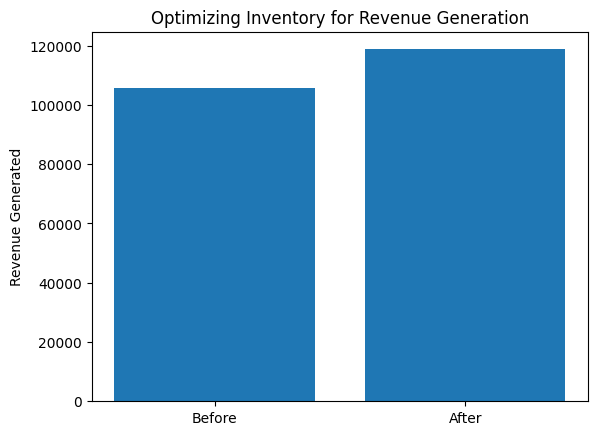


Before Optimizing Inventory, Revenue = $105773.80
After Optimizing Inventory, Revenue = $118743.06


In [ ]:
#Jack: Inventory optimization from ABC Analysis

B_products_removal = B_products.reset_index()
B_remove = B_products_removal['%_quant_sold'][28:].sum()
print(f"A {B_remove:.0f}% removal of inventory from B Products")
A_products_addition = B_products_removal['quantity_sold'][28:].sum() / A_products['quantity_sold'].count()

C_products_removal = C_products.reset_index()
C_remove = C_products_removal['%_quant_sold'][15:].sum()
print(f"A {C_remove:.0f}% removal of inventory from C Products")
A_products_addition_2 = C_products_removal['quantity_sold'][15:].sum() / A_products['quantity_sold'].count()

price_avg = sales_df.groupby('product_id')['price'].mean()

A_products_new = A_products['quantity_sold'] + A_products_addition + A_products_addition_2
A_products_new = pd.merge(A_products_new,A_products['%_tycv'],on='product_id',how='inner')
prod_cost_merge_1 = pd.merge(price_avg,A_products_new,on='product_id',how='inner')
prod_cost_merge_1 =prod_cost_merge_1.sort_values(by='%_tycv',ascending=False)
prod_cost_merge_1['Revenue'] = prod_cost_merge_1['quantity_sold'] * prod_cost_merge_1['price']
A_revenue = prod_cost_merge_1['Revenue'].sum()

B_products_cut = B_products[:28]
prod_cost_merge_2 = pd.merge(price_avg,B_products_cut,on='product_id',how='inner')
prod_cost_merge_2 =prod_cost_merge_2.sort_values(by='%_tycv',ascending=False)
prod_cost_merge_2['Revenue'] = prod_cost_merge_2['quantity_sold'] * prod_cost_merge_2['price']
B_revenue = prod_cost_merge_2['Revenue'].sum()

prod_cost_merge_3 = pd.merge(price_avg,C_products,on='product_id',how='inner')
prod_cost_merge_3 =prod_cost_merge_3.sort_values(by='%_tycv',ascending=False)
prod_cost_merge_3['Revenue'] = prod_cost_merge_3['quantity_sold'] * prod_cost_merge_3['price']
C_revenue = prod_cost_merge_3['Revenue'].sum()

after_revenue = A_revenue + B_revenue + C_revenue

prod_cost_merge = pd.merge(price_avg,prod_cost,on='product_id',how='inner')
prod_cost_merge = prod_cost_merge.sort_values(by='%_tycv',ascending=False)
prod_cost_merge['Revenue'] = prod_cost_merge['quantity_sold'] * prod_cost_merge['price']

before_revenue = prod_cost_merge['Revenue'].sum()

print(f"We have now optimzed A Products inventory percentage to {(A_products_quant + B_remove + C_remove):.0f}%")
print(f"We have now optimzed B Products inventory percentage to {(B_products_quant - B_remove):.0f}%")
print(f"We have now optimzed C Products inventory percentage to {(C_products_quant - C_remove):.0f}%")
print()

x = ['Before','After']
y = [before_revenue,after_revenue]

plt.bar(x,y)
plt.title("Optimizing Inventory for Revenue Generation")
plt.ylabel("Revenue Generated")
plt.show()
print()
print(f"Before Optimizing Inventory, Revenue = ${before_revenue:.2f}")
print(f"After Optimizing Inventory, Revenue = ${after_revenue:.2f}")


===== Re-Order Point for product P0118 =====
Average stockout cost per unit: $35.52
Average storage cost per unit: $0.49
Perishable? (0 = No; 1 = Yes): 0
Service Level: 95% (z = 1.64)
Average Weekly Demand: 5.07 units
Standard Deviation of Demand: 2.64 units
Average Lead Time: 9.50 days
Standard Deviation of Lead Time: 3.54 days
EOQ (Units to Order): 92
Safety Stock: 32 units
Reorder Point (ROP): 81 units


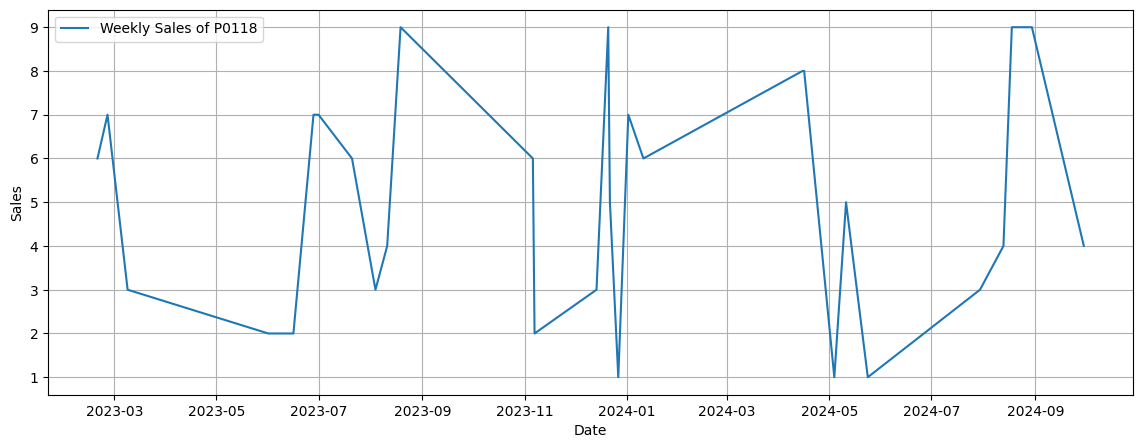

In [ ]:
#Jack: Re-Order point for product P0118 as the example for presentation

sales = sales_df[['date','quantity_sold','product_id','store_id']]
P0118 = sales[sales['product_id'] == "P0118"]
P0118 = P0118.set_index(P0118['date'])
P0118 = P0118.drop('date',axis=1)
P0118 = P0118.sort_values(by='date',ascending=True)
P0118['Week_that_Sold'] = np.arange(1, len(P0118) + 1)

invent_P0118 = inventory_df[inventory_df['product_id'] == "P0118"]
P0118_stock_sum = invent_P0118['stock_level'].sum()

P0118_invent_sales = invent_sales[invent_sales['product_id'] == "P0118"]
P0118_avg_stock_cost = P0118_invent_sales['total_cost_per_unit'].mean()
P0118_order_cost = P0118_invent_sales['ordering_cost'].mean()

P0118_supplier = supplier_df[supplier_df['product_id'] == "P0118"]

P0118_mean_demand = P0118['quantity_sold'].mean()
P0118_std_demand = P0118['quantity_sold'].std()

P0118_mean_leadtime = P0118_supplier['lead_time_days'].mean()
P0118_std_leadtime = P0118_supplier['lead_time_days'].std()

product_value = P0118_avg_stock_cost
annual_carrying_cost = 0.30
carrying_cost = product_value * annual_carrying_cost
ordering_cost = P0118_order_cost
service_level = 0.95
z_score = norm.ppf(service_level)

annual_demand = P0118_mean_demand * 365
EOQ = np.sqrt((2 * annual_demand * ordering_cost) / carrying_cost)
Sigma_d = np.sqrt((P0118_mean_leadtime * P0118_std_demand ** 2) + (P0118_std_leadtime * P0118_mean_demand )** 2)
safety_stock = z_score * Sigma_d
ROP = P0118_mean_demand * P0118_mean_leadtime + safety_stock


perishability = product_df[product_df['product_id'] == "P0118"]
P0118_stockout_cost = inventory_df[inventory_df['product_id'] == "P0118"]
P0118_info = pd.merge(perishability,P0118_stockout_cost,on='product_id',how='inner')
stockout_cost = P0118_info['stockout_cost'].mean()
P0118_storage_cost = P0118_info['storage_cost'].mean()

print("===== Re-Order Point for product P0118 =====")
print(f"Average stockout cost per unit: ${stockout_cost:.2f}")
print(f"Average storage cost per unit: ${P0118_storage_cost:.2f}")
print(f"Perishable? (0 = No; 1 = Yes): {P0118_info['perishable_flag'].sum()}")
print(f"Service Level: {service_level * 100:.0f}% (z = {z_score:.2f})")
print(f"Average Weekly Demand: {P0118_mean_demand:.2f} units")
print(f"Standard Deviation of Demand: {P0118_std_demand:.2f} units")
print(f"Average Lead Time: {P0118_mean_leadtime:.2f} days")
print(f"Standard Deviation of Lead Time: {P0118_std_leadtime:.2f} days")
print(f"EOQ (Units to Order): {EOQ:.0f}")
print(f"Safety Stock: {safety_stock:.0f} units")
print(f"Reorder Point (ROP): {ROP:.0f} units")

plt.figure(figsize=(14, 5))
plt.plot(P0118.index, P0118['quantity_sold'], label='Weekly Sales of P0118')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()


Supplier Evaluation

In [ ]:
#Shilpa: Evaluate and rank suppliers using multi-criteria scoring

supplier_stats = supplier_df.groupby('supplier_id').agg(
    unit_cost=('unit_cost', 'mean'),
    lead_time_days=('lead_time_days', 'mean'),
    on_time_delivery_rate=('on_time_delivery_rate', 'mean'),
    defect_rate=('defect_rate', 'mean')
).reset_index()

#Rank suppliers  (lower rank = better rank)
supplier_stats['LeadTime_Rank'] = supplier_stats['lead_time_days'].rank(method='dense')
supplier_stats['OnTimeDelivery_Rank'] = supplier_stats['on_time_delivery_rate'].rank(method='dense', ascending=False)
supplier_stats['DefectRate_Rank'] = supplier_stats['defect_rate'].rank(method='dense')
supplier_stats['unit_cost_Rank'] = supplier_stats['unit_cost'].rank(method='dense')


print("Top 10 cheapest Suppliers:")
print(supplier_stats.sort_values(by='unit_cost').head(10))

Top 10 cheapest Suppliers:
  supplier_id  unit_cost  lead_time_days  on_time_delivery_rate  defect_rate  \
8       SUP09   4.662424        8.787879               0.832424     0.062121   
7       SUP08   4.699388        8.326531               0.852857     0.053878   
6       SUP07   4.962973        7.243243               0.867027     0.057568   
0       SUP01   5.176512        8.023256               0.833488     0.053256   
2       SUP03   5.334848        7.848485               0.863939     0.052121   
1       SUP02   5.349459        8.486486               0.876757     0.059459   
5       SUP06   5.562162        8.108108               0.874595     0.053784   
4       SUP05   5.601020        7.693878               0.857959     0.054490   
3       SUP04   5.668485        7.787879               0.860303     0.056364   
9       SUP10   5.980625        8.906250               0.850000     0.057813   

   LeadTime_Rank  OnTimeDelivery_Rank  DefectRate_Rank  unit_cost_Rank  
8            9.0   

/tmp/ipython-input-2973283147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


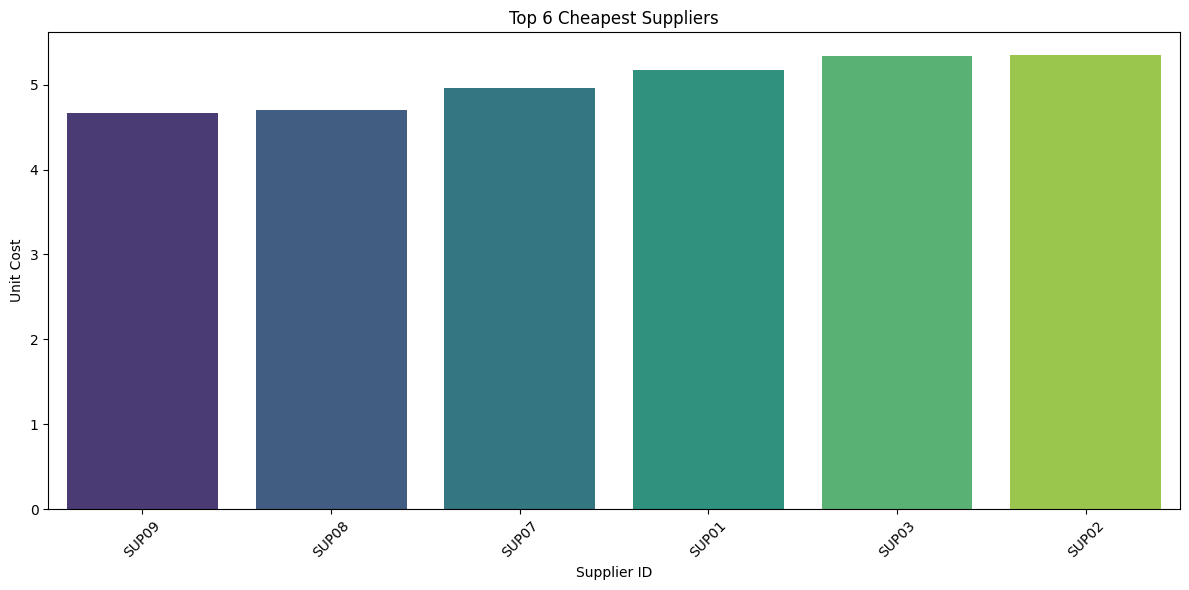

In [ ]:
# shilpa: Make a graph of top 6 cheapest suppliers
top_suppliers = supplier_stats.sort_values(by='unit_cost').head(6)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_suppliers,
    x='supplier_id',
    y='unit_cost',
    palette='viridis'
    )
plt.title("Top 6 Cheapest Suppliers")
plt.xlabel("Supplier ID")
plt.ylabel("Unit Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualize performance across suppliers

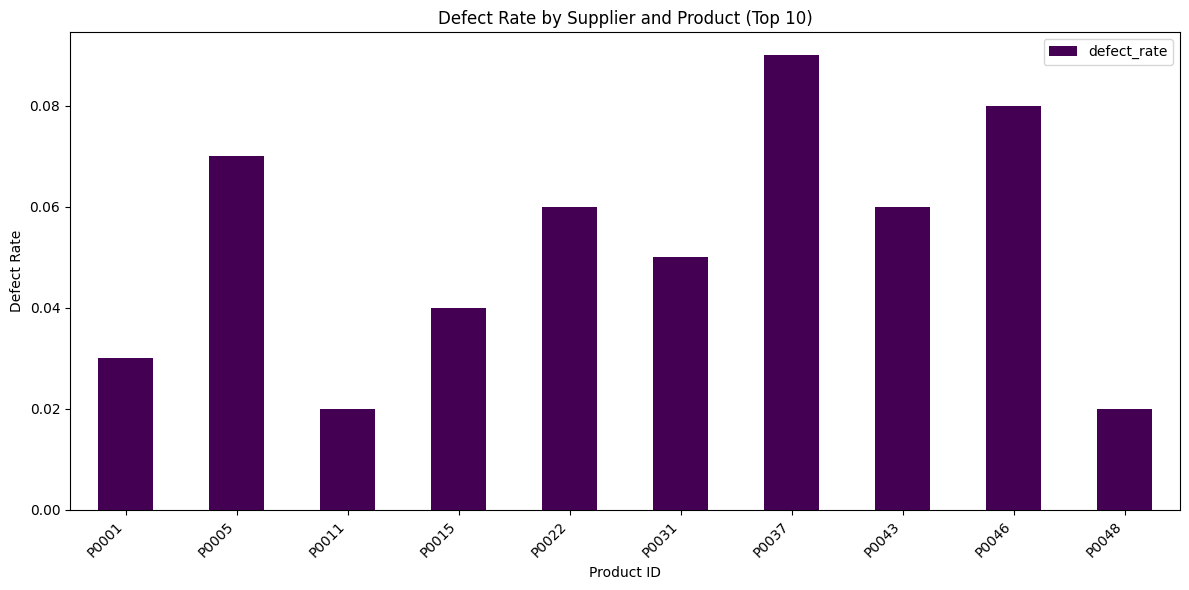

In [ ]:
#shilpa: Calculate defect rate per supplier and product
supplier_product_defect_rate = supplier_df.groupby(['supplier_id', 'product_id']).agg({
    'defect_rate': 'mean'
}).reset_index()

# Visualize defect rate per supplier and product for the top 30 entries
supplier_product_defect_rate.head(10).plot(
    kind='bar',
    x='product_id',
    y='defect_rate',
    figsize=(12, 6),
    colormap='viridis',
    title='Defect Rate by Supplier and Product (Top 10)'
)
plt.ylabel("Defect Rate")
plt.xlabel("Product ID")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

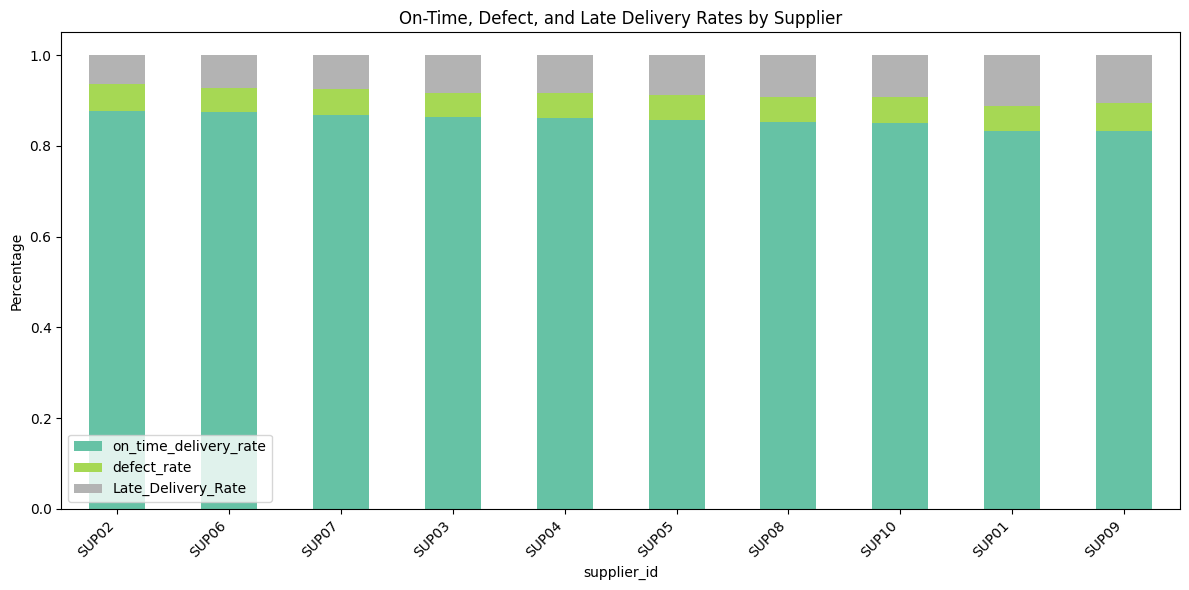

In [ ]:
#shilpa:  Stacked Bar Plot of On-Time delivery rate vs defect rate Deliveries
supplier_stats = supplier_df.groupby('supplier_id').agg({
    'on_time_delivery_rate': 'mean',
    'defect_rate': 'mean'
}).reset_index()

# Prepare data for stacked bar plot (assuming on-time + defect = 100%)
supplier_stats['Late_Delivery_Rate'] = 1 - supplier_stats['on_time_delivery_rate'] - supplier_stats['defect_rate'] # Assuming any non-on-time and non-defective is late

# Sort by on-time delivery rate for better visualization
supplier_stats = supplier_stats.sort_values('on_time_delivery_rate', ascending=False)

# Plot stacked bar chart
supplier_stats.set_index('supplier_id')[['on_time_delivery_rate', 'defect_rate', 'Late_Delivery_Rate']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Set2',
    title='On-Time, Defect, and Late Delivery Rates by Supplier'
)
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#shilpa: Rank top 5 suppliers for each product categories based on average lead_time days

supplier_df.groupby("supplier_id")["lead_time_days"].mean().sort_values()

,lead_time_days
supplier_id,
SUP07,7.243243
SUP05,7.693878
SUP04,7.787879
SUP03,7.848485
SUP01,8.023256
SUP06,8.108108
SUP08,8.326531
SUP02,8.486486
SUP09,8.787879


In [ ]:
#shilpa:  Average lead time by Supplier and Product
supplier_product_leadtime = supplier_df.groupby(["supplier_id", "product_id"])["lead_time_days"].mean().reset_index()

# Sort values for better readability
supplier_product_leadtime = supplier_product_leadtime.sort_values(by=["supplier_id", "lead_time_days"])

# Display summary
supplier_product_leadtime.head(10)



,supplier_id,product_id,lead_time_days
10,SUP01,P0052,2.0
14,SUP01,P0071,2.0
20,SUP01,P0088,2.0
23,SUP01,P0102,2.0
25,SUP01,P0109,2.0
9,SUP01,P0048,3.0
17,SUP01,P0075,3.0
5,SUP01,P0031,4.0
3,SUP01,P0015,5.0
4,SUP01,P0022,5.0


finding the best supplier based on lead time days is,  supplier 1 because average lead time is 2.

In [ ]:
#Shilpa: Rank the best supplier of each product category

# Merge supplier_df with product_df to get category information
merged_data = pd.merge(supplier_df, product_df, on='product_id')

# Group by product_id and category and find the supplier with the minimum lead time for each product
best_supplier_per_product = merged_data.loc[merged_data.groupby(['product_id', 'category'])['lead_time_days'].idxmin()]

# Find the best supplier for each category (supplier with the lowest average lead time within that category)
best_supplier_per_category = best_supplier_per_product.groupby('category').apply(
    lambda x: x.loc[x['lead_time_days'].idxmin()]
).reset_index(drop=True)

# Select and rename relevant columns for the final table
best_supplier_table = best_supplier_per_category[['category', 'supplier_id', 'lead_time_days', 'product_id']]
best_supplier_table = best_supplier_table.rename(columns={
    'lead_time_days': 'Min_Lead_Time_Days',
    'supplier_id': 'Best_Supplier_ID',
    'product_id': 'Example_Product_ID'
})


print("Best Supplier for Each Product Category (Based on Minimum Lead Time):")
display(best_supplier_table)


Best Supplier for Each Product Category (Based on Minimum Lead Time):


/tmp/ipython-input-2652965320.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_supplier_per_category = best_supplier_per_product.groupby('category').apply(


,category,Best_Supplier_ID,Min_Lead_Time_Days,Example_Product_ID
0,Bakery,SUP06,2,P0043
1,Beverages,SUP02,2,P0012
2,Dairy,SUP01,2,P0109
3,Frozen,SUP07,2,P0015
4,Meat,SUP09,2,P0031
5,Produce,SUP01,2,P0052
